# Dynamic QFT + Measurement (QFT+M)

[Bäumer et al., *Quantum Fourier Transform using Dynamic Circuits*](https://arxiv.org/abs/2403.09514) (Fig. 1) 를 참고한 **unitary vs dynamic QFT+M** 벤치마크 노트북입니다.

- **Unitary QFT+M**: `O(n²)` two-qubit phase gates (+ SWAP 없음)
- **Dynamic QFT+M**: mid-circuit measure + semi-classical fan-out (`if_test`) → `O(n)` feed-forward, **연결성 제약 없음**
- **지표**: 논문 Eq. (2) **process fidelity** `F_proc` (입력 `σ_k* = QFT†|k⟩` 샘플링; prep = `H^⊗n` + virtual `RZ`, entangling prep 없음)
- **QEM**: `dynamic_cnot_qem_mthree.ipynb` 와 동일 — SamplerV2 twirling + **M3 readout mitigation**
- **DD**: dynamic 회로는 Runtime에서 `if_test` 와 함께 DD 불가 (논문 FC-DD 는 HW pulse 레벨)

기본값 `USE_REAL_HARDWARE=False` → **noisy Aer** (`from_backend`) 로 로컬 실행.


In [1]:
from collections import defaultdict

from qiskit import QuantumCircuit, ClassicalRegister
from qiskit.circuit.library import QFT
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_circuit_layout
from qiskit_ibm_runtime import QiskitRuntimeService, Batch, SamplerV2 as Sampler
from qiskit_aer import AerSimulator
from qiskit.circuit import IfElseOp

import matplotlib.pyplot as plt
import mthree
import numpy as np


def configure_sampler_qem(sampler):
    """SamplerV2 error-suppression options (applied on real hardware; Aer ignores)."""
    sampler.options.twirling.enable_gates = True
    sampler.options.twirling.enable_measure = True
    sampler.options.twirling.strategy = "active-accum"
    sampler.options.twirling.num_randomizations = "auto"
    sampler.options.twirling.shots_per_randomization = "auto"
    # DD cannot be combined with dynamic circuits (ControlFlowOp / if_test).
    sampler.options.dynamical_decoupling.enable = False
    return sampler


## Step 0 — QFT+M 회로 정의

**입력 prep** (논문): σ_k* = QFT†|k⟩ 를 `X|k⟩ → H^⊗n → virtual RZ` 로 준비합니다. IQFT의 controlled-phase를 k에 대해 semi-classical `P→RZ`로 바꾸므로 prep 구간에 **two-qubit gate가 없고**, RZ는 IBM HW에서 virtual Z(frame)로 스케줄됩니다.

**QFT+M body** — 논문 Fig. 1(b): qubit `m = n-1 … 0` 순으로 `H → measure →` 측정 bit 로 아래 qubit 들에 **semi-classical fan-out** phase.

Qiskit `QFT(do_swaps=False)` 와 unitary 로 동치인 dynamic 스케줄입니다 (deferred measurement).


Ideal check passed: prep+unitary QFT gives |000101⟩
Prep gates (H + virtual RZ): OrderedDict({'h': 6, 'x': 2, 'rz': 2})


/var/folders/0r/1fm22r751p1c2kg8rnsvj_xh0000gn/T/ipykernel_98257/3641473856.py:19: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  decomp = QFT(n, inverse=True, do_swaps=False).decompose()
/var/folders/0r/1fm22r751p1c2kg8rnsvj_xh0000gn/T/ipykernel_98257/3641473856.py:73: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  sv = Statevector.from_instruction(prepare_sigma_k_star(n, k).compose(QFT(n, do_swaps=False)))


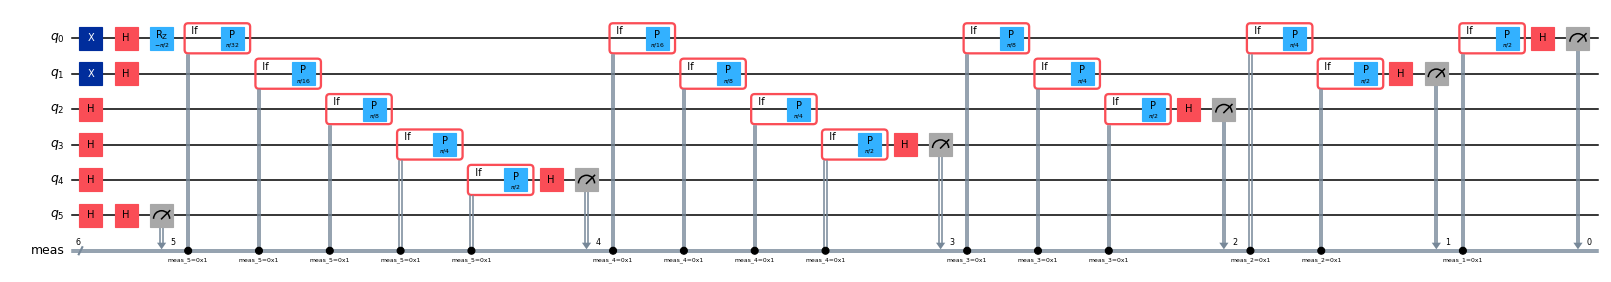

In [2]:
NUM_QUBITS = 6  # demo size for circuit drawing


def bitstring(k, n):
    return format(k, f"0{n}b")


def prepare_sigma_k_star(n, k):
    """Prepare σ_k* = QFT†|k⟩ via X|k⟩ + H^⊗n + virtual RZ (no entangling prep).

    Semiclassical IQFT: CP gates in QFT† become fixed P/RZ once |k⟩ is known.
    Matches full IQFT prep exactly; avoids O(n²) two-qubit gates in the prep block.
    """
    qc = QuantumCircuit(n, name=f"prep_k{k}")
    bits = list(reversed(bitstring(k, n)))
    for l, b in enumerate(bits):
        if b == "1":
            qc.x(l)
    decomp = QFT(n, inverse=True, do_swaps=False).decompose()
    rz_angles = defaultdict(float)
    for inst in decomp.data:
        name = inst.operation.name
        qubits = [q._index for q in inst.qubits]
        if name in ("cp", "cu1") and bits[qubits[0]] == "1":
            rz_angles[qubits[1]] += inst.operation.params[0]
    for q in range(n):
        qc.h(q)
    for q in range(n):
        ang = rz_angles.get(q, 0.0)
        if abs(ang) > 1e-12:
            qc.rz(ang, q)
    return qc


def qft_unitary(n):
    """Standard unitary QFT+M (measure all qubits at the end)."""
    cr = ClassicalRegister(n, name="meas")
    qc = QuantumCircuit(n, name="QFT_unitary")
    qc.add_register(cr)
    qc.compose(QFT(n, do_swaps=False), qubits=range(n), inplace=True)
    qc.measure(range(n), cr)
    return qc


def qft_dynamic(n):
    """Dynamic QFT+M — O(n) mid-circuit measurements + if_test fan-out."""
    cr = ClassicalRegister(n, name="meas")
    qc = QuantumCircuit(n, name="QFT_dynamic")
    qc.add_register(cr)
    for m in range(n - 1, -1, -1):
        qc.h(m)
        qc.measure(m, cr[m])
        for l in range(m):
            angle = 2 * np.pi / (2 ** (m - l + 1))
            with qc.if_test((cr[m], 1)):
                qc.p(angle, l)
    return qc


def qftm_circuit(n, k, dynamic=True):
    qc = prepare_sigma_k_star(n, k)
    body = qft_dynamic(n) if dynamic else qft_unitary(n)
    qc.compose(body, inplace=True)
    qc.name = f"QFTM_{'dyn' if dynamic else 'uni'}_n{n}_k{k}"
    return qc


# Quick sanity check (ideal simulation)
from qiskit.quantum_info import Statevector

n = NUM_QUBITS
k = 5
sv = Statevector.from_instruction(prepare_sigma_k_star(n, k).compose(QFT(n, do_swaps=False)))
assert abs(sv.probabilities_dict()[bitstring(k, n)] - 1.0) < 1e-9
print(f"Ideal check passed: prep+unitary QFT gives |{bitstring(k, n)}⟩")
print(f"Prep gates (H + virtual RZ): {prepare_sigma_k_star(n, k).count_ops()}")

demo = qftm_circuit(NUM_QUBITS, k=3, dynamic=True)
demo.draw(output="mpl", fold=-1, scale=0.55)


## Scaling benchmark (논문 Fig. 2 스타일)

Process fidelity (논문 Eq. 2):

$$
F_{\mathrm{proc}} \approx \frac{m}{m-1}\left[\frac{1}{m}\sum_l \sqrt{P(k_l)}\right]^2 - \frac{1}{m(m-1)}\sum_l P(k_l)
$$

여기서 `P(k_l) = Pr(k_l | noisy QFT(σ_{k_l}^*))` 입니다.


In [3]:
# -------------------------QEM config-------------------------
APPLY_READOUT_MITIGATION = True
USE_REAL_HARDWARE = False

# Lightweight Aer QFT uses non-Clifford phase gates, so keep the local grid modest.
# The default standalone AerSimulator supports 31 qubits on this machine.
N_QUBIT_LIST = [4, 6, 8, 10, 12]
M_INPUTS = 8          # random k samples per n (paper: m=20)
NUM_TRIALS = 5
SHOTS = 1024
RNG = np.random.default_rng(2026)

# Pre-draw input bitstrings per n (fixed across trials for reproducibility)
INPUT_SAMPLES = {
    n: RNG.choice(2**n, size=min(M_INPUTS, 2**n), replace=False).tolist()
    for n in N_QUBIT_LIST
}
for n, ks in INPUT_SAMPLES.items():
    print(f"n={n}: sample k = {ks}")


n=4: sample k = [7, 1, 5, 14, 11, 4, 0, 6]
n=6: sample k = [38, 60, 10, 18, 61, 5, 49, 46]
n=8: sample k = [116, 112, 40, 160, 164, 86, 71, 206]
n=10: sample k = [13, 674, 1012, 457, 169, 373, 475, 845]
n=12: sample k = [3944, 3264, 2485, 3578, 3916, 2165, 3826, 856]


In [4]:
# -------------------------Step 1: build logical circuits-------------------------
circuits_dyn = []
circuits_uni = []

for n in N_QUBIT_LIST:
    for k in INPUT_SAMPLES[n]:
        circuits_dyn.append(qftm_circuit(n, k, dynamic=True))
        circuits_uni.append(qftm_circuit(n, k, dynamic=False))

print(f"Dynamic pubs: {len(circuits_dyn)}")
print(f"Unitary pubs: {len(circuits_uni)}")


Dynamic pubs: 40
Unitary pubs: 40


/var/folders/0r/1fm22r751p1c2kg8rnsvj_xh0000gn/T/ipykernel_98257/3641473856.py:19: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  decomp = QFT(n, inverse=True, do_swaps=False).decompose()
/var/folders/0r/1fm22r751p1c2kg8rnsvj_xh0000gn/T/ipykernel_98257/3641473856.py:40: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.compose(QFT(n, do_swaps=False), qubits=range(n), inplace=True)


In [5]:
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)

def make_ghz_noise_model(
    one_qubit_error=0.001,
    two_qubit_error=0.01,
    reset_error=0.01,
    readout_error=0.02,
):
    """Create a simple, reproducible noise model for the GHZ comparison."""
    noise_model = NoiseModel()

    error_1q = depolarizing_error(one_qubit_error, 1)
    error_2q = depolarizing_error(two_qubit_error, 2)
    error_reset = pauli_error(
        [("X", reset_error), ("I", 1 - reset_error)]
    )
    error_readout = ReadoutError(
        [
            [1 - readout_error, readout_error],
            [readout_error, 1 - readout_error],
        ]
    )

    noise_model.add_all_qubit_quantum_error(
        error_1q,
        ["h", "sx", "x", "y", "z", "sdg"],
    )
    noise_model.add_all_qubit_quantum_error(error_2q, ["cx", "cz", "ecr"])
    noise_model.add_all_qubit_quantum_error(error_reset, ["reset"])
    noise_model.add_all_qubit_readout_error(error_readout)
    return noise_model

# -------------------------Step 2: backend & layouts-------------------------

backend = FakeFez()
if "if_else" not in backend.target.operation_names:
    backend.target.add_instruction(IfElseOp, name="if_else")

sweep_noise_model = make_ghz_noise_model()
# QFT uses arbitrary phase rotations, so Aer stabilizer simulation is invalid here.
# Keep this as a lightweight standalone simulator, not AerSimulator.from_backend(backend).
backend_sim = AerSimulator(
    method="automatic",
    noise_model=sweep_noise_model,
    seed_simulator=42,
)
execution_backend = backend if USE_REAL_HARDWARE else backend_sim

# service = QiskitRuntimeService(name="YONSEI-SKQD")
# backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend_sim = AerSimulator(method="automatic", noise_model=sweep_noise_model)
# execution_backend = backend if USE_REAL_HARDWARE else backend_sim
print(f"Target backend: {backend}")
print(f"Execution backend: {execution_backend} (USE_REAL_HARDWARE={USE_REAL_HARDWARE})")

lf_qubits = backend.properties().to_dict()["general_qlists"]
max_n = max(N_QUBIT_LIST)
base_chain = [val["qubits"] for val in lf_qubits if val["name"] == f"lf_{max_n}"][0]

chosen_layouts = {n: base_chain[:n] for n in N_QUBIT_LIST}
print("Layouts:", chosen_layouts)


Target backend: <qiskit_ibm_runtime.fake_provider.backends.fez.fake_fez.FakeFez object at 0x13e447fb0>
Execution backend: AerSimulator('aer_simulator'
             noise_model=<NoiseModel on ['z', 'sdg', 'x', 'reset', 'sx', 'ecr', 'measure', 'y', 'h', 'cz', 'cx']>) (USE_REAL_HARDWARE=False)
Layouts: {4: [125, 126, 127, 137], 6: [125, 126, 127, 137, 147, 146], 8: [125, 126, 127, 137, 147, 146, 145, 144], 10: [125, 126, 127, 137, 147, 146, 145, 144, 143, 142], 12: [125, 126, 127, 137, 147, 146, 145, 144, 143, 142, 141, 140]}


In [6]:
# -------------------------Step 2b: M3 calibration-------------------------
PHYSICAL_BENCHMARK_QUBITS = sorted({q for layout in chosen_layouts.values() for q in layout})

if USE_REAL_HARDWARE:
    M3_CAL_QUBITS = PHYSICAL_BENCHMARK_QUBITS
else:
    local_num_qubits = execution_backend.configuration().n_qubits
    if max(N_QUBIT_LIST) > local_num_qubits:
        raise ValueError(
            f"Lightweight Aer backend supports {local_num_qubits} qubits, "
            f"but max(N_QUBIT_LIST)={max(N_QUBIT_LIST)}. "
            "Reduce N_QUBIT_LIST or use AerSimulator.from_backend()."
        )
    M3_CAL_QUBITS = list(range(max(N_QUBIT_LIST)))

m3_mit = mthree.M3Mitigation(execution_backend)
m3_cal_method = "balanced" if USE_REAL_HARDWARE else "independent"
m3_mit.cals_from_system(
    M3_CAL_QUBITS,
    method=m3_cal_method,
    rep_delay=None,
)
print(
    f"M3 calibrated on {len(M3_CAL_QUBITS)} qubits via {execution_backend} "
    f"(method={m3_cal_method})"
)


M3 calibrated on 12 qubits via AerSimulator('aer_simulator'
             noise_model=<NoiseModel on ['z', 'sdg', 'x', 'reset', 'sx', 'ecr', 'measure', 'y', 'h', 'cz', 'cx']>) (method=independent)


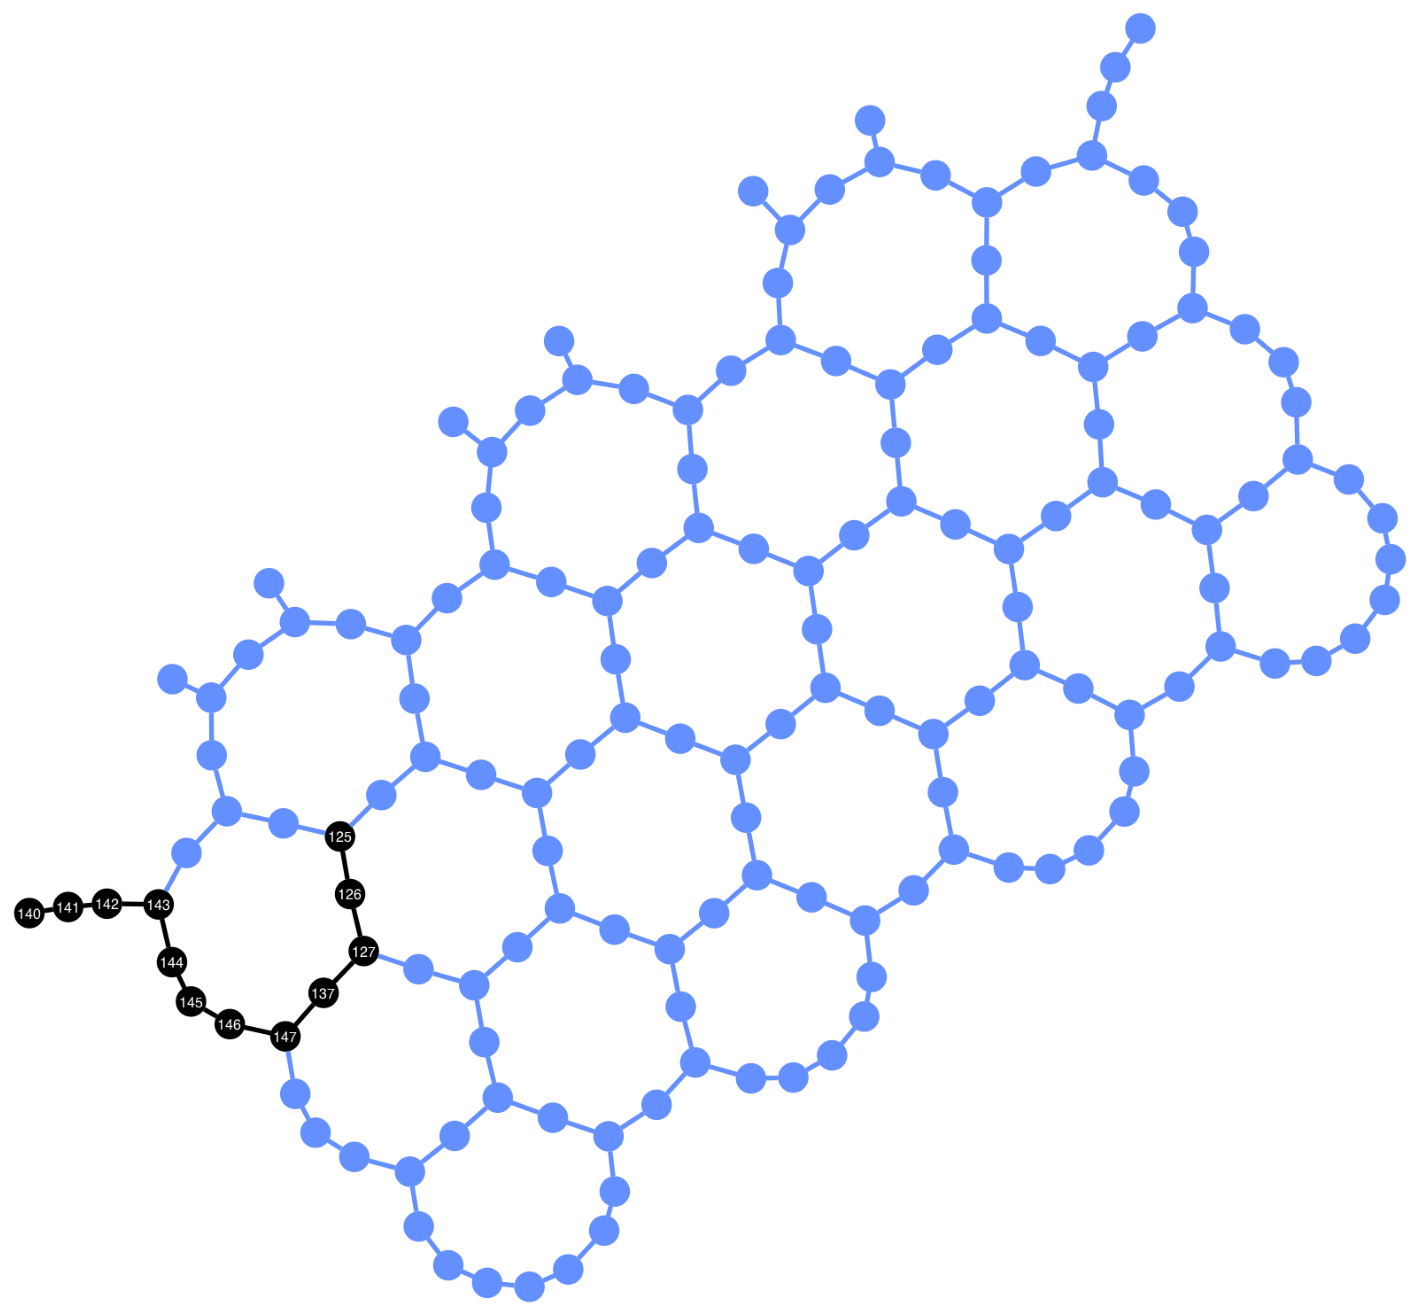

In [7]:
# -------------------------Transpile to ISA-------------------------
isa_dyn = []
isa_uni = []

for qc in circuits_dyn:
    n = qc.num_qubits
    pm = generate_preset_pass_manager(
        optimization_level=3,
        backend=backend,
        initial_layout=chosen_layouts[n],
    )
    isa_dyn.append(pm.run(qc))

for qc in circuits_uni:
    n = qc.num_qubits
    pm = generate_preset_pass_manager(
        optimization_level=3,
        backend=backend,
        initial_layout=chosen_layouts[n],
    )
    isa_uni.append(pm.run(qc))

plot_circuit_layout(isa_dyn[-1], backend=backend, view="physical")


In [8]:
# -------------------------QEM / analysis helpers-------------------------

def meas_qubit_mapping(layout):
    """Qubits for M3 correction: physical on hardware, local 0..n-1 on lightweight Aer."""
    if USE_REAL_HARDWARE:
        return list(layout)
    return list(range(len(layout)))


def get_meas_counts(pub_result):
    return pub_result.data.meas.get_counts()


def m3_correct_counts(mit, counts, layout):
    return mit.apply_correction(counts, meas_qubit_mapping(layout))


def success_probability(counts, k, n, mitigated=False):
    key = bitstring(k, n)
    total = sum(counts.values())
    if total == 0:
        return 0.0
    p = counts.get(key, 0) / total
    if mitigated:
        # M3 returns quasi-probabilities; clip before Eq. (2).
        p = float(np.clip(p, 0.0, 1.0))
    return p


def estimate_process_fidelity(probabilities):
    """Paper Eq. (2) from list of success probabilities P(k_l)."""
    m = len(probabilities)
    if m == 0:
        return np.nan
    if m == 1:
        return float(np.clip(probabilities[0], 0.0, 1.0))
    probs = np.clip(np.asarray(probabilities, dtype=float), 0.0, 1.0)
    term1 = (m / (m - 1)) * (np.mean(np.sqrt(probs)) ** 2)
    term2 = np.sum(probs) / (m * (m - 1))
    return float(np.clip(term1 - term2, 0.0, 1.0))


def aggregate_qftm_results(jobs, n_qubit_list, input_samples, chosen_layouts, mit=None):
    """Return dict n -> list of trial F_proc values."""
    by_n = {n: [] for n in n_qubit_list}

    for job in jobs:
        result = job.result()
        idx = 0
        trial_probs = {n: [] for n in n_qubit_list}
        for n in n_qubit_list:
            for k in input_samples[n]:
                counts = get_meas_counts(result[idx])
                if mit is not None:
                    counts = m3_correct_counts(mit, counts, chosen_layouts[n])
                trial_probs[n].append(
                    success_probability(counts, k, n, mitigated=(mit is not None))
                )
                idx += 1
        for n in n_qubit_list:
            by_n[n].append(estimate_process_fidelity(trial_probs[n]))
    return by_n


In [9]:
# -------------------------Step 3: execute-------------------------
jobs_dyn = []
jobs_uni = []

with Batch(backend=execution_backend) as batch:
    sampler = configure_sampler_qem(Sampler(mode=batch))
    sampler.options.environment.job_tags = ["TUT_QFTM"]
    print("Sampler options:", sampler.options.twirling, sampler.options.dynamical_decoupling)
    for _ in range(NUM_TRIALS):
        jobs_dyn.append(sampler.run(isa_dyn, shots=SHOTS))
        jobs_uni.append(sampler.run(isa_uni, shots=SHOTS))

print(f"Submitted {NUM_TRIALS} trials × dynamic + unitary")


Sampler options: TwirlingOptions(enable_gates=True, enable_measure=True, num_randomizations='auto', shots_per_randomization='auto', strategy='active-accum') DynamicalDecouplingOptions(enable=False, sequence_type=Unset, extra_slack_distribution=Unset, scheduling_method=Unset, skip_reset_qubits=Unset)


/Users/jojeongbin/miniforge3/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:274: UserWarning: Options {'dynamical_decoupling': {'enable': False}, 'twirling': {'enable_gates': True, 'enable_measure': True, 'num_randomizations': 'auto', 'shots_per_randomization': 'auto', 'strategy': 'active-accum'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


Submitted 5 trials × dynamic + unitary


In [10]:
# -------------------------Step 3b: process fidelity-------------------------
f_proc_dyn_raw = aggregate_qftm_results(jobs_dyn, N_QUBIT_LIST, INPUT_SAMPLES, chosen_layouts)
f_proc_uni_raw = aggregate_qftm_results(jobs_uni, N_QUBIT_LIST, INPUT_SAMPLES, chosen_layouts)

f_proc_dyn_m3 = f_proc_uni_m3 = None
if APPLY_READOUT_MITIGATION:
    f_proc_dyn_m3 = aggregate_qftm_results(
        jobs_dyn, N_QUBIT_LIST, INPUT_SAMPLES, chosen_layouts, mit=m3_mit
    )
    f_proc_uni_m3 = aggregate_qftm_results(
        jobs_uni, N_QUBIT_LIST, INPUT_SAMPLES, chosen_layouts, mit=m3_mit
    )

for n in N_QUBIT_LIST:
    raw_u = np.mean(f_proc_uni_raw[n])
    raw_d = np.mean(f_proc_dyn_raw[n])
    line = f"n={n:2d}  unitary F_proc={raw_u:.3f}  dynamic F_proc={raw_d:.3f}"
    if f_proc_dyn_m3 is not None:
        line += f"  | +M3: uni={np.mean(f_proc_uni_m3[n]):.3f}, dyn={np.mean(f_proc_dyn_m3[n]):.3f}"
    print(line)


n= 4  unitary F_proc=0.751  dynamic F_proc=0.917  | +M3: uni=0.810, dyn=0.991
n= 6  unitary F_proc=0.462  dynamic F_proc=0.880  | +M3: uni=0.517, dyn=0.988
n= 8  unitary F_proc=0.241  dynamic F_proc=0.838  | +M3: uni=0.278, dyn=0.975
n=10  unitary F_proc=0.149  dynamic F_proc=0.813  | +M3: uni=0.178, dyn=0.984
n=12  unitary F_proc=0.062  dynamic F_proc=0.765  | +M3: uni=0.076, dyn=0.963


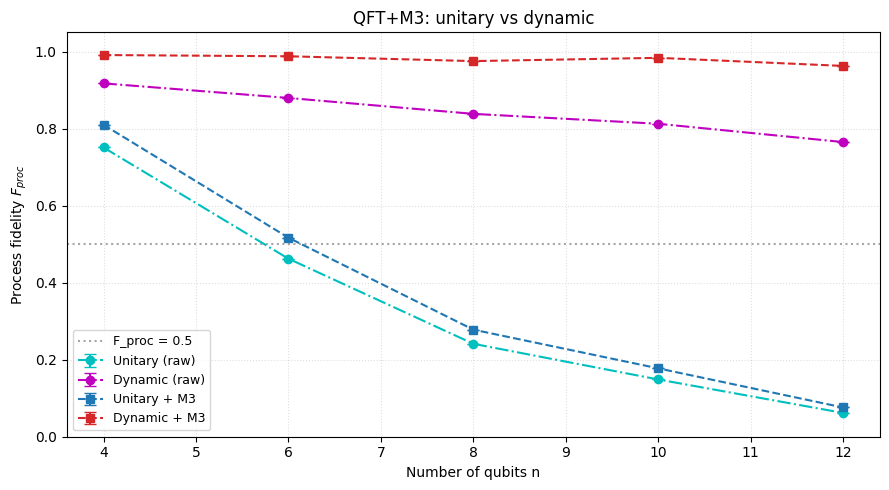

In [11]:
# -------------------------Step 4: plot (Fig. 2a style)-------------------------

def mean_std(dict_by_n):
    means = [np.mean(dict_by_n[n]) for n in N_QUBIT_LIST]
    stds = [np.std(dict_by_n[n]) for n in N_QUBIT_LIST]
    return means, stds

mu_u, sd_u = mean_std(f_proc_uni_raw)
mu_d, sd_d = mean_std(f_proc_dyn_raw)

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(N_QUBIT_LIST, mu_u, yerr=sd_u, fmt="o-.", color="c", capsize=4, label="Unitary (raw)")
ax.errorbar(N_QUBIT_LIST, mu_d, yerr=sd_d, fmt="o-.", color="m", capsize=4, label="Dynamic (raw)")

if f_proc_dyn_m3 is not None:
    mu_um, sd_um = mean_std(f_proc_uni_m3)
    mu_dm, sd_dm = mean_std(f_proc_dyn_m3)
    ax.errorbar(N_QUBIT_LIST, mu_um, yerr=sd_um, fmt="s--", color="tab:blue", capsize=4, label="Unitary + M3")
    ax.errorbar(N_QUBIT_LIST, mu_dm, yerr=sd_dm, fmt="s--", color="tab:red", capsize=4, label="Dynamic + M3")

ax.axhline(0.5, ls=":", color="gray", alpha=0.7, label="F_proc = 0.5")
ax.set_xlabel("Number of qubits n")
ax.set_ylabel(r"Process fidelity $F_{proc}$")
ax.set_title("QFT+M3: unitary vs dynamic")
ax.set_ylim(0, 1.05)
ax.grid(linestyle=":", alpha=0.4)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Optional — Fig. 2(c) periodic state demo

$\sum_{k=0}^{N/4-1} |3+4k
angle$ ($N=2^n$) 를 준비한 뒤 QFT+M 출력 분포를 비교합니다. 피크 4개(각 ~1/4)가 ideal에 가까우면 dynamic 구현이 유리함을 시각적으로 확인할 수 있습니다.


/var/folders/0r/1fm22r751p1c2kg8rnsvj_xh0000gn/T/ipykernel_98257/3641473856.py:40: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.compose(QFT(n, do_swaps=False), qubits=range(n), inplace=True)
/var/folders/0r/1fm22r751p1c2kg8rnsvj_xh0000gn/T/ipykernel_98257/1192309328.py:58: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  ideal_probs = sv_periodic.evolve(QFT(n_periodic, do_swaps=False)).probabilities_dict()


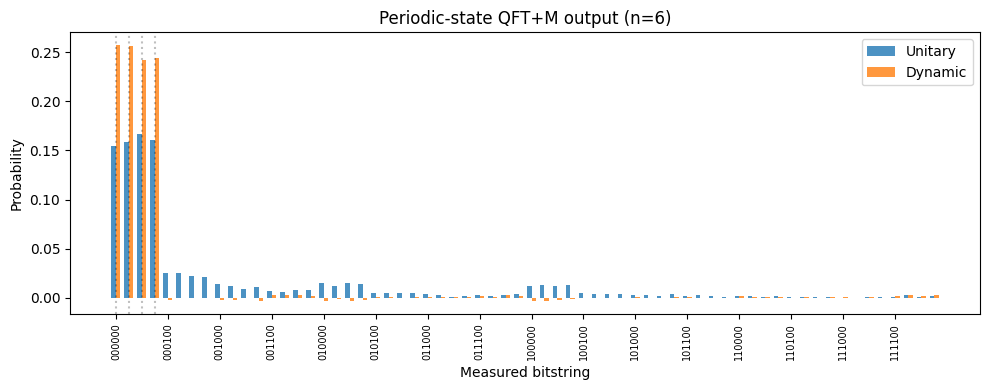

Ideal peak bitstrings: [np.str_('000000'), np.str_('000001'), np.str_('000010'), np.str_('000011')]


In [12]:
def prepare_periodic_state(n):
    from qiskit.circuit.library import StatePreparation
    from qiskit.quantum_info import Statevector

    sv = None
    for k in range(0, 2**n // 4):
        basis = format(3 + 4 * k, f"0{n}b")
        qc_k = QuantumCircuit(n)
        for i, b in enumerate(reversed(basis)):
            if b == "1":
                qc_k.x(i)
        psi = Statevector.from_instruction(qc_k)
        sv = psi if sv is None else sv + psi
    sv = sv / np.linalg.norm(sv.data)
    return StatePreparation(sv.data, label="periodic")


def periodic_benchmark(n, shots=4096, dynamic=True):
    sv_inst = prepare_periodic_state(n)
    qc = QuantumCircuit(n, name="periodic_qftm")
    qc.append(sv_inst, range(n))
    qc.compose(qft_dynamic(n) if dynamic else qft_unitary(n), inplace=True)
    pm = generate_preset_pass_manager(
        optimization_level=1,
        backend=backend,
        initial_layout=chosen_layouts[n],
    )
    isa = pm.run(qc)
    with Batch(backend=execution_backend) as batch:
        sampler = configure_sampler_qem(Sampler(mode=batch))
        job = sampler.run([isa], shots=shots)
    counts = get_meas_counts(job.result()[0])
    if APPLY_READOUT_MITIGATION:
        counts = m3_correct_counts(m3_mit, counts, chosen_layouts[n])
    total = sum(counts.values())
    probs = {k: v / total for k, v in counts.items()}
    return probs


# Set n_periodic <= max(N_QUBIT_LIST); use n=6 for a lighter demo
n_periodic = min(6, max(N_QUBIT_LIST))
probs_uni = periodic_benchmark(n_periodic, dynamic=False)
probs_dyn = periodic_benchmark(n_periodic, dynamic=True)

# Ideal peaks from noiseless QFT of the periodic state
from qiskit.quantum_info import Statevector

sv_periodic = None
for k in range(0, 2 ** (n_periodic - 2)):
    basis = bitstring(3 + 4 * k, n_periodic)
    qc_k = QuantumCircuit(n_periodic)
    for i, b in enumerate(reversed(basis)):
        if b == "1":
            qc_k.x(i)
    psi = Statevector.from_instruction(qc_k)
    sv_periodic = psi if sv_periodic is None else sv_periodic + psi
sv_periodic = sv_periodic / np.linalg.norm(sv_periodic.data)
ideal_probs = sv_periodic.evolve(QFT(n_periodic, do_swaps=False)).probabilities_dict()
ideal_peaks = [b for b, p in ideal_probs.items() if p > 0.1]

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(2**n_periodic)
labels = [bitstring(i, n_periodic) for i in x]
width = 0.35
ax.bar(x - width / 2, [probs_uni.get(l, 0) for l in labels], width=width, label="Unitary", alpha=0.8)
ax.bar(x + width / 2, [probs_dyn.get(l, 0) for l in labels], width=width, label="Dynamic", alpha=0.8)
for peak in ideal_peaks:
    ax.axvline(int(peak, 2), color="k", ls=":", alpha=0.25)
ax.set_xticks(x[:: max(1, len(x)//16)])
ax.set_xticklabels([labels[i] for i in range(0, len(labels), max(1, len(labels)//16))], rotation=90, fontsize=7)
ax.set_xlabel("Measured bitstring")
ax.set_ylabel("Probability")
ax.set_title(f"Periodic-state QFT+M output (n={n_periodic})")
ax.legend()
plt.tight_layout()
plt.show()
print("Ideal peak bitstrings:", ideal_peaks)
